# Classification Project: Online Shoppers Purchasing Intention
## Notebook 4: Class Balancing Methodology and Experimental Comparison

In this supplementary analysis, we rigorously evaluate the impact of different class balancing techniques on the dataset's severe 85/15 imbalance. 

To isolate the effect of the sampling methodology, we fix the classification algorithm to our optimized XGBoost architecture. We will evaluate each sampling technique using 5-Fold Stratified Cross-Validation on the training set, extracting the Macro F1-Score, and the specific Precision and Recall for the minority class (True/Purchase).

### Techniques Evaluated:
1. **Baseline (None):** No balancing applied.
2. **Random Under-Sampling (RUS):** Randomly deletes majority class instances until classes are equal.
3. **Random Over-Sampling (ROS):** Randomly duplicates minority class instances.
4. **SMOTE (1.0):** Generates synthetic minority instances to achieve a 50/50 balance.
5. **SMOTE (0.7):** Generates synthetic instances to reach a 70/100 ratio (Our Champion).
6. **ADASYN:** Generates synthetic data based on the local density of minority class examples, focusing on instances that are harder to learn.


In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.base import BaseSampler
from sklearn.neighbors import LocalOutlierFactor

print("--- 1. LOADING D_TRAIN ---")
current_dir = os.path.dirname(os.path.abspath('__file__'))
parent_dir = os.path.abspath(os.path.join(current_dir, '..')) 

file_path = os.path.join(parent_dir, 'online_shoppers_intention.csv')

if not os.path.exists(file_path):
    print(f"CRITICAL ERROR: Cannot find the dataset at {file_path}")
else:
    df = pd.read_csv(file_path).dropna().reset_index(drop=True)
    df['Weekend'] = df['Weekend'].astype(int)
    df['Revenue'] = df['Revenue'].astype(int)
    df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

    X = df.drop(columns=['Revenue'])
    y = df['Revenue']

    from sklearn.model_selection import train_test_split
    # We evaluate exclusively on D_train to preserve the integrity of D_test
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
    print(f"Training data ready: {X_train.shape[0]} samples.")

--- 1. LOADING D_TRAIN ---
Training data ready: 9864 samples.


In [2]:
# We must include our custom LOF cleaner to maintain methodological consistency
class LOF_Sampler(BaseSampler):
    _sampling_type = 'clean-sampling'
    _parameter_constraints = {
        "n_neighbors": [int],
        "contamination": [float, str],
        "sampling_strategy": [str, type(None)]
    }

    def __init__(self, n_neighbors=100, contamination=0.05, sampling_strategy="auto"):
        self.n_neighbors = n_neighbors
        self.contamination = contamination
        self.sampling_strategy = sampling_strategy 
        
    def _fit_resample(self, X, y):
        lof = LocalOutlierFactor(n_neighbors=self.n_neighbors, contamination=self.contamination)
        outlier_flags = lof.fit_predict(X)
        mask = outlier_flags == 1
        if isinstance(X, pd.DataFrame) or hasattr(X, 'iloc'):
            return X.iloc[mask], y.iloc[mask]
        else:
            return X[mask], y[mask]

### 2. Experimental Execution
We define a dictionary of samplers. For each sampler, we construct an `imblearn` pipeline consisting of:
`LOF_Sampler -> StandardScaler -> [Selected Sampler] -> XGBoost`

*Note: The Baseline pipeline simply omits the sampling step.*

In [3]:
print("--- 2. EXECUTING SAMPLING EXPERIMENTS ---")

# Define the samplers to test
samplers = {
    "Baseline (No Balancing)": "passthrough",
    "Under-Sampling (RUS)": RandomUnderSampler(random_state=42),
    "Over-Sampling (ROS)": RandomOverSampler(random_state=42),
    "SMOTE (Ratio 1.0)": SMOTE(random_state=42, sampling_strategy=1.0),
    "SMOTE (Ratio 0.7)": SMOTE(random_state=42, sampling_strategy=0.7),
    "ADASYN": ADASYN(random_state=42)
}

# Define the fixed, optimized XGBoost classifier
xgb_model = XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    learning_rate=0.05,
    max_depth=5,
    n_estimators=100
)

# Define robust scoring metrics
scoring = {
    'macro_f1': make_scorer(f1_score, average='macro'),
    'minority_recall': make_scorer(recall_score, pos_label=1),
    'minority_precision': make_scorer(precision_score, pos_label=1)
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

print("Running 5-Fold Cross-Validation for each technique. Please wait...\n")

for name, sampler in samplers.items():
    print(f"Evaluating: {name}...")
    
    # Build the dynamic pipeline
    if sampler == "passthrough":
        pipeline = ImbPipeline([
            ('lof', LOF_Sampler(n_neighbors=100, contamination=0.05)),
            ('scaler', StandardScaler()),
            ('classifier', xgb_model)
        ])
    else:
        pipeline = ImbPipeline([
            ('lof', LOF_Sampler(n_neighbors=100, contamination=0.05)),
            ('scaler', StandardScaler()),
            ('sampler', sampler),
            ('classifier', xgb_model)
        ])
        
    # Execute Cross-Validation
    cv_scores = cross_validate(pipeline, X_train, y_train, cv=cv_strategy, scoring=scoring, n_jobs=-1)
    
    # Store results
    results.append({
        'Strategy': name,
        'Macro F1': cv_scores['test_macro_f1'].mean(),
        'Recall (Purchase)': cv_scores['test_minority_recall'].mean(),
        'Precision (Purchase)': cv_scores['test_minority_precision'].mean()
    })

# Convert results to a DataFrame for easy viewing
results_df = pd.DataFrame(results)
print("\n--- EXPERIMENT RESULTS ---")
print(results_df.to_string(index=False))

--- 2. EXECUTING SAMPLING EXPERIMENTS ---
Running 5-Fold Cross-Validation for each technique. Please wait...

Evaluating: Baseline (No Balancing)...
Evaluating: Under-Sampling (RUS)...
Evaluating: Over-Sampling (ROS)...
Evaluating: SMOTE (Ratio 1.0)...
Evaluating: SMOTE (Ratio 0.7)...
Evaluating: ADASYN...

--- EXPERIMENT RESULTS ---
               Strategy  Macro F1  Recall (Purchase)  Precision (Purchase)
Baseline (No Balancing)  0.805260           0.604847              0.739505
   Under-Sampling (RUS)  0.775165           0.857124              0.514944
    Over-Sampling (ROS)  0.787895           0.824376              0.548222
      SMOTE (Ratio 1.0)  0.811614           0.760159              0.628952
      SMOTE (Ratio 0.7)  0.815887           0.741149              0.651095
                 ADASYN  0.807347           0.758179              0.619497


### 3. Visualizing the Impact of Class Balancing
We plot the results to visually demonstrate the trade-off between Precision and Recall that occurs when manipulating the class distribution.

--- 3. VISUALIZING METHODOLOGY COMPARISON ---


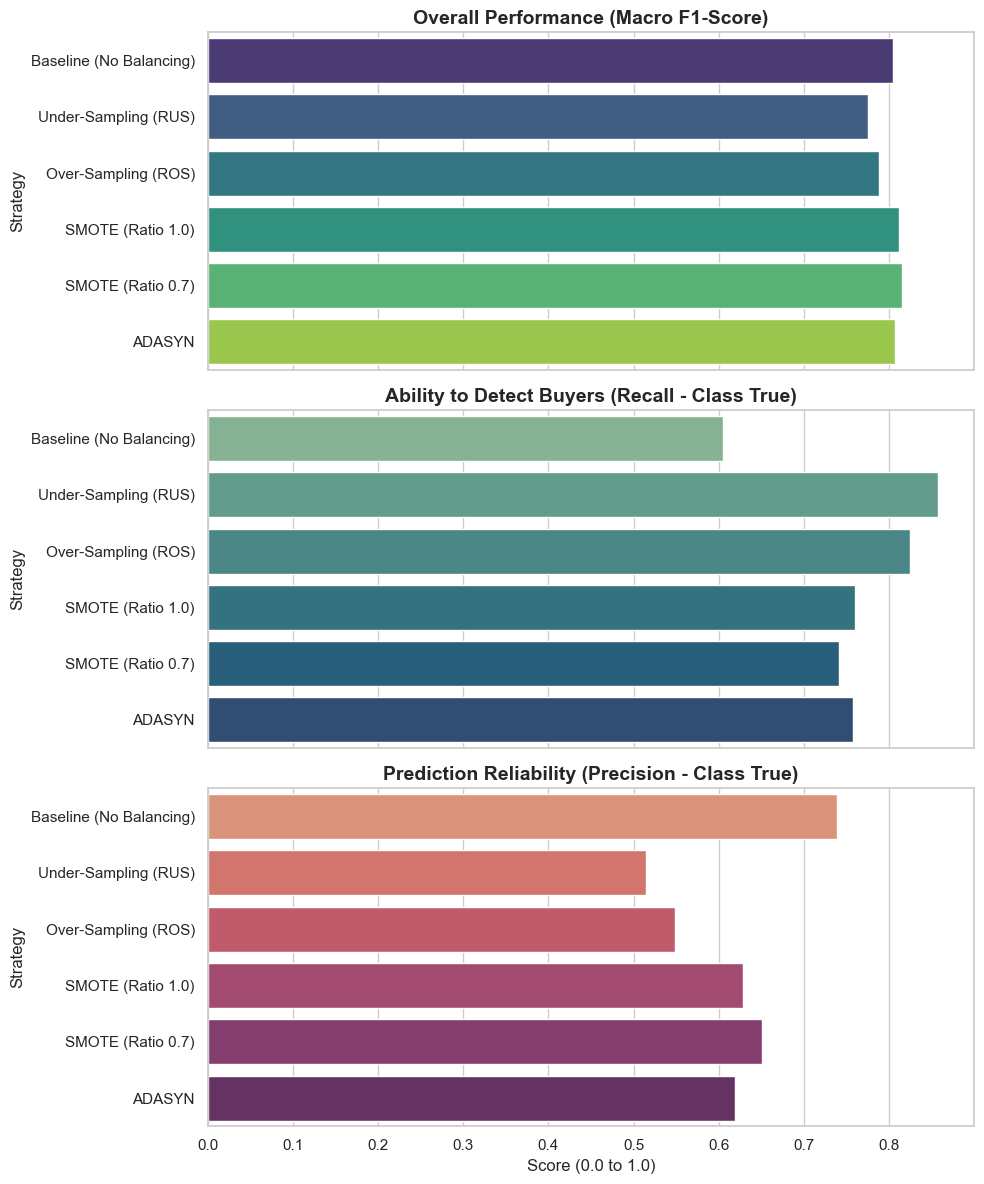


EXPECTED OBSERVATIONS FOR YOUR PRESENTATION:
1. Baseline (No Balancing): High Precision, very low Recall. The model ignores the minority class.
2. Under-Sampling (RUS): High Recall, but terrible Precision. Deleting 85% of the data destroys the model's ability to recognize non-buyers.
3. SMOTE (0.7): Achieves the highest Macro F1 by finding the perfect mathematical compromise between Precision and Recall.


In [5]:
print("--- 3. VISUALIZING METHODOLOGY COMPARISON ---")

# Set up the matplotlib figure
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True)
sns.set_theme(style="whitegrid")

# Plot 1: Macro F1-Score (The overall balancing metric)
sns.barplot(
    x='Macro F1', y='Strategy', data=results_df, ax=axes[0], 
    hue='Strategy', palette='viridis', orient='h', legend=False
)
axes[0].set_title('Overall Performance (Macro F1-Score)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')

# Plot 2: Minority Recall (Ability to find all actual buyers)
sns.barplot(
    x='Recall (Purchase)', y='Strategy', data=results_df, ax=axes[1], 
    hue='Strategy', palette='crest', orient='h', legend=False
)
axes[1].set_title('Ability to Detect Buyers (Recall - Class True)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('')

# Plot 3: Minority Precision (Accuracy when predicting a purchase)
sns.barplot(
    x='Precision (Purchase)', y='Strategy', data=results_df, ax=axes[2], 
    hue='Strategy', palette='flare', orient='h', legend=False
)
axes[2].set_title('Prediction Reliability (Precision - Class True)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Score (0.0 to 1.0)')

plt.tight_layout()
plt.show()

print("\nEXPECTED OBSERVATIONS FOR YOUR PRESENTATION:")
print("1. Baseline (No Balancing): High Precision, very low Recall. The model ignores the minority class.")
print("2. Under-Sampling (RUS): High Recall, but terrible Precision. Deleting 85% of the data destroys the model's ability to recognize non-buyers.")
print("3. SMOTE (0.7): Achieves the highest Macro F1 by finding the perfect mathematical compromise between Precision and Recall.")